# UC3 Layer 2 — Isolation Forest (Structural Anomaly Detection)

**Goal:** Train an Isolation Forest on benign-only CSIC 2010 HTTP data to detect structurally anomalous requests.

**Dataset:** CSIC 2010 — parsed CSVs from `uc3_csic2010_parser.ipynb`

**Split:** File-boundary (author-designated, no temporal ordering in CSIC 2010):
- **Train:** `normalTrafficTraining.csv` (benign only)
- **Test:** `normalTrafficTest.csv` (label=0) + `anomalousTrafficTest.csv` (label=1)

**Feature vector (4-dim):** `request_length`, `special_char_count`, `url_entropy`, `param_count`

**Training:** `contamination="auto"`, `n_estimators=200`, benign-only

**Pipeline:**
1. Load parsed CSVs
2. Feature extraction (single function for train & inference parity)
3. Scale features (`StandardScaler` fit on train only)
4. Train Isolation Forest
5. Threshold sweep (precision-recall curve)
6. Evaluation: confusion matrix, classification report, PR-AUC, ROC-AUC
7. Feature distribution analysis (benign vs attack)
8. False negative analysis
9. Persist scaler + model via `joblib`

In [1]:
import os
import numpy as np
import pandas as pd
import math
import joblib
from urllib.parse import unquote, urlparse, parse_qs

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    precision_recall_curve, average_precision_score,
    roc_auc_score, roc_curve,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ── Configuration ──────────────────────────────────────────
CSV_DIR   = "./data"     
MODEL_DIR = "./models"
os.makedirs(MODEL_DIR, exist_ok=True)

STRUCTURAL_FEATURE_COLS = [
    "request_length", "special_char_count", "special_char_ratio",
    "url_entropy", "body_entropy", "param_count",
    "max_param_value_length", "url_path_depth", "has_body",
]
VOCAB_FEATURE_COLS = [
    "unknown_param_name_count",
    "unknown_param_name_ratio",
    "max_param_name_min_edit_dist",
]
FEATURE_COLS = STRUCTURAL_FEATURE_COLS + VOCAB_FEATURE_COLS

RANDOM_STATE = 42

VAL_SIZE    = 0.2      # held-out benign fraction for threshold tuning
TARGET_FPR  = 0.05     # target false positive rate

print("Ready.")

Ready.


## 1. Load Parsed CSVs

In [2]:
df_train = pd.read_csv(os.path.join(CSV_DIR, "normalTrafficTraining.csv"))
df_test_benign = pd.read_csv(os.path.join(CSV_DIR, "normalTrafficTest.csv"))
df_test_attack = pd.read_csv(os.path.join(CSV_DIR, "anomalousTrafficTest.csv"))

df_test = pd.concat([df_test_benign, df_test_attack], ignore_index=True)

print(f"Train (benign only): {len(df_train):>6,}")
print(f"Test  (benign):      {len(df_test_benign):>6,}")
print(f"Test  (attack):      {len(df_test_attack):>6,}")
print(f"Test  (combined):    {len(df_test):>6,}")
print(f"\nTest label distribution:\n{df_test['label'].value_counts().to_dict()}")

Train (benign only): 36,000
Test  (benign):      36,000
Test  (attack):      25,065
Test  (combined):    61,065

Test label distribution:
{0: 36000, 1: 25065}


## 2. Feature Extraction

URL-decode **before** computing features so `special_char_count` and `url_entropy`
are consistent between raw logs (which may be percent-encoded) and inference input.

In [3]:
SPECIAL_CHARS = set("'\";<>(){}[]|$`!@#%^*~")

def _shannon_entropy(s: str) -> float:
    if not s:
        return 0.0
    length = len(s)
    freq = {}
    for ch in s:
        freq[ch] = freq.get(ch, 0) + 1
    return -sum((c / length) * math.log2(c / length) for c in freq.values())


def _count_special_chars(s: str) -> int:
    return sum(1 for ch in s if ch in SPECIAL_CHARS)


def _count_params(url: str, body: str, content_type: str) -> int:
    n = 0
    # URL query params
    try:
        parsed = urlparse(url)
        n += len(parse_qs(parsed.query, keep_blank_values=True))
    except Exception:
        pass
    # POST body params (only for form-urlencoded)
    if isinstance(body, str) and isinstance(content_type, str):
        if "application/x-www-form-urlencoded" in content_type.lower():
            try:
                n += len(parse_qs(body, keep_blank_values=True))
            except Exception:
                pass
    return n

def _max_param_value_length(url: str, body: str, content_type: str) -> int:
    vals = []

    try:
        parsed = urlparse(url)
        for v_list in parse_qs(parsed.query, keep_blank_values=True).values():
            vals.extend(v_list)
    except Exception:
        pass

    if isinstance(body, str) and isinstance(content_type, str):
        if "application/x-www-form-urlencoded" in content_type.lower():
            try:
                for v_list in parse_qs(body, keep_blank_values=True).values():
                    vals.extend(v_list)
            except Exception:
                pass

    return max((len(v) for v in vals), default=0)


def _url_path_depth(url: str) -> int:
    try:
        path = urlparse(url).path
        segments = [s for s in path.split("/") if s]
        return len(segments)
    except Exception:
        return 0


def extract_features(df: pd.DataFrame) -> pd.DataFrame:
    # URL-decode first
    decoded_url  = df["url"].fillna("").apply(lambda u: unquote(u))
    decoded_body = df["body"].fillna("")

    # Reconstruct full request string for request_length
    full_request = (
        df["method"].fillna("") + " "
        + decoded_url + " "
        + df["protocol"].fillna("") + "\n"
        + df["headers_raw"].fillna("") + "\n\n"
        + decoded_body
    )

    combined = decoded_url + decoded_body
    spec_count = combined.apply(_count_special_chars)
    combined_len = combined.str.len().replace(0, 1)  # avoid div-by-zero

    features = pd.DataFrame({
        "request_length":       full_request.str.len(),
        "special_char_count":   spec_count,
        "special_char_ratio":   spec_count / combined_len,
        "url_entropy":          decoded_url.apply(_shannon_entropy),
        "body_entropy":         decoded_body.apply(_shannon_entropy),
        "param_count":          [
            _count_params(u, b, ct)
            for u, b, ct in zip(
                decoded_url, decoded_body, df["content_type"].fillna(""),
            )
        ],
        "max_param_value_length": [
            _max_param_value_length(u, b, ct)
            for u, b, ct in zip(
                decoded_url, decoded_body, df["content_type"].fillna(""),
            )
        ],
        "url_path_depth":       decoded_url.apply(_url_path_depth),
        "has_body":             (decoded_body.str.len() > 0).astype(int),
    })
    return features


print("Feature extraction function defined.")

class ParamVocab:
    """Parameter-name vocabulary learned from benign traffic."""

    def __init__(self):
        self.known_names: set = set()

    @staticmethod
    def _parse_params(url: str, body: str, content_type: str) -> dict:
        params = {}
        try:
            parsed = urlparse(unquote(url))
            params.update(parse_qs(parsed.query, keep_blank_values=True))
        except Exception:
            pass
        if isinstance(body, str) and isinstance(content_type, str):
            if "application/x-www-form-urlencoded" in content_type.lower():
                try:
                    params.update(parse_qs(body, keep_blank_values=True))
                except Exception:
                    pass
        return params

    @staticmethod
    def _levenshtein(s1: str, s2: str) -> int:
        if len(s1) < len(s2):
            return ParamVocab._levenshtein(s2, s1)
        if not s2:
            return len(s1)
        prev = list(range(len(s2) + 1))
        for i, c1 in enumerate(s1):
            curr = [i + 1]
            for j, c2 in enumerate(s2):
                curr.append(min(
                    curr[j] + 1,
                    prev[j + 1] + 1,
                    prev[j] + (0 if c1 == c2 else 1),
                ))
            prev = curr
        return prev[-1]

    def fit(self, df: pd.DataFrame) -> "ParamVocab":
        self.known_names = set()
        for url, body, ct in zip(
            df["url"].fillna(""),
            df["body"].fillna(""),
            df["content_type"].fillna(""),
        ):
            self.known_names.update(
                self._parse_params(url, body, ct).keys()
            )
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        records = []
        for url, body, ct in zip(
            df["url"].fillna(""),
            df["body"].fillna(""),
            df["content_type"].fillna(""),
        ):
            names = list(self._parse_params(url, body, ct).keys())
            total = len(names)

            if total == 0:
                records.append((0, 0.0, 0))
                continue

            unknown_count = sum(1 for n in names if n not in self.known_names)

            # Edit distance only for unknown names (known → 0, skip)
            max_min_ed = 0
            for name in names:
                if name in self.known_names:
                    continue
                if not self.known_names:
                    min_ed = len(name)
                else:
                    min_ed = min(
                        self._levenshtein(name, kn)
                        for kn in self.known_names
                    )
                max_min_ed = max(max_min_ed, min_ed)

            records.append((
                unknown_count,
                unknown_count / total,
                max_min_ed,
            ))

        return pd.DataFrame(
            records,
            columns=VOCAB_FEATURE_COLS,
            index=df.index,
        )


print("ParamVocab defined.")

Feature extraction function defined.
ParamVocab defined.


## 3. Compute Feature Matrices

In [4]:
vocab = ParamVocab().fit(df_train)
print(f"Param vocab: {len(vocab.known_names)} unique names")
print(f"  Names: {sorted(vocab.known_names)}")

X_train = pd.concat([
    extract_features(df_train),
    vocab.transform(df_train),
], axis=1)

X_test = pd.concat([
    extract_features(df_test),
    vocab.transform(df_test),
], axis=1)

y_test = df_test["label"].values

print(f"\nTrain feature matrix: {X_train.shape}")  # expect (36000, 12)
print(f"Test  feature matrix: {X_test.shape}")     # expect (61065, 12)

# Verify vocab features are zero for benign training data
print(f"\nVocab features on train (should be all zeros):")
print(X_train[VOCAB_FEATURE_COLS].describe().round(4))

print(f"\nVocab features on test:")
print(X_test[VOCAB_FEATURE_COLS].describe().round(4))

Param vocab: 20 unique names
  Names: ['B1', 'B2', 'apellidos', 'cantidad', 'ciudad', 'cp', 'direccion', 'dni', 'email', 'errorMsg', 'id', 'login', 'modo', 'nombre', 'ntc', 'password', 'precio', 'provincia', 'pwd', 'remember']

Train feature matrix: (36000, 12)
Test  feature matrix: (61065, 12)

Vocab features on train (should be all zeros):
       unknown_param_name_count  unknown_param_name_ratio  \
count                   36000.0                   36000.0   
mean                        0.0                       0.0   
std                         0.0                       0.0   
min                         0.0                       0.0   
25%                         0.0                       0.0   
50%                         0.0                       0.0   
75%                         0.0                       0.0   
max                         0.0                       0.0   

       max_param_name_min_edit_dist  
count                       36000.0  
mean                          

## 4. Feature Distribution Analysis

Compare benign (train + test) vs attack distributions to confirm the 4 features
have discriminative power before training.

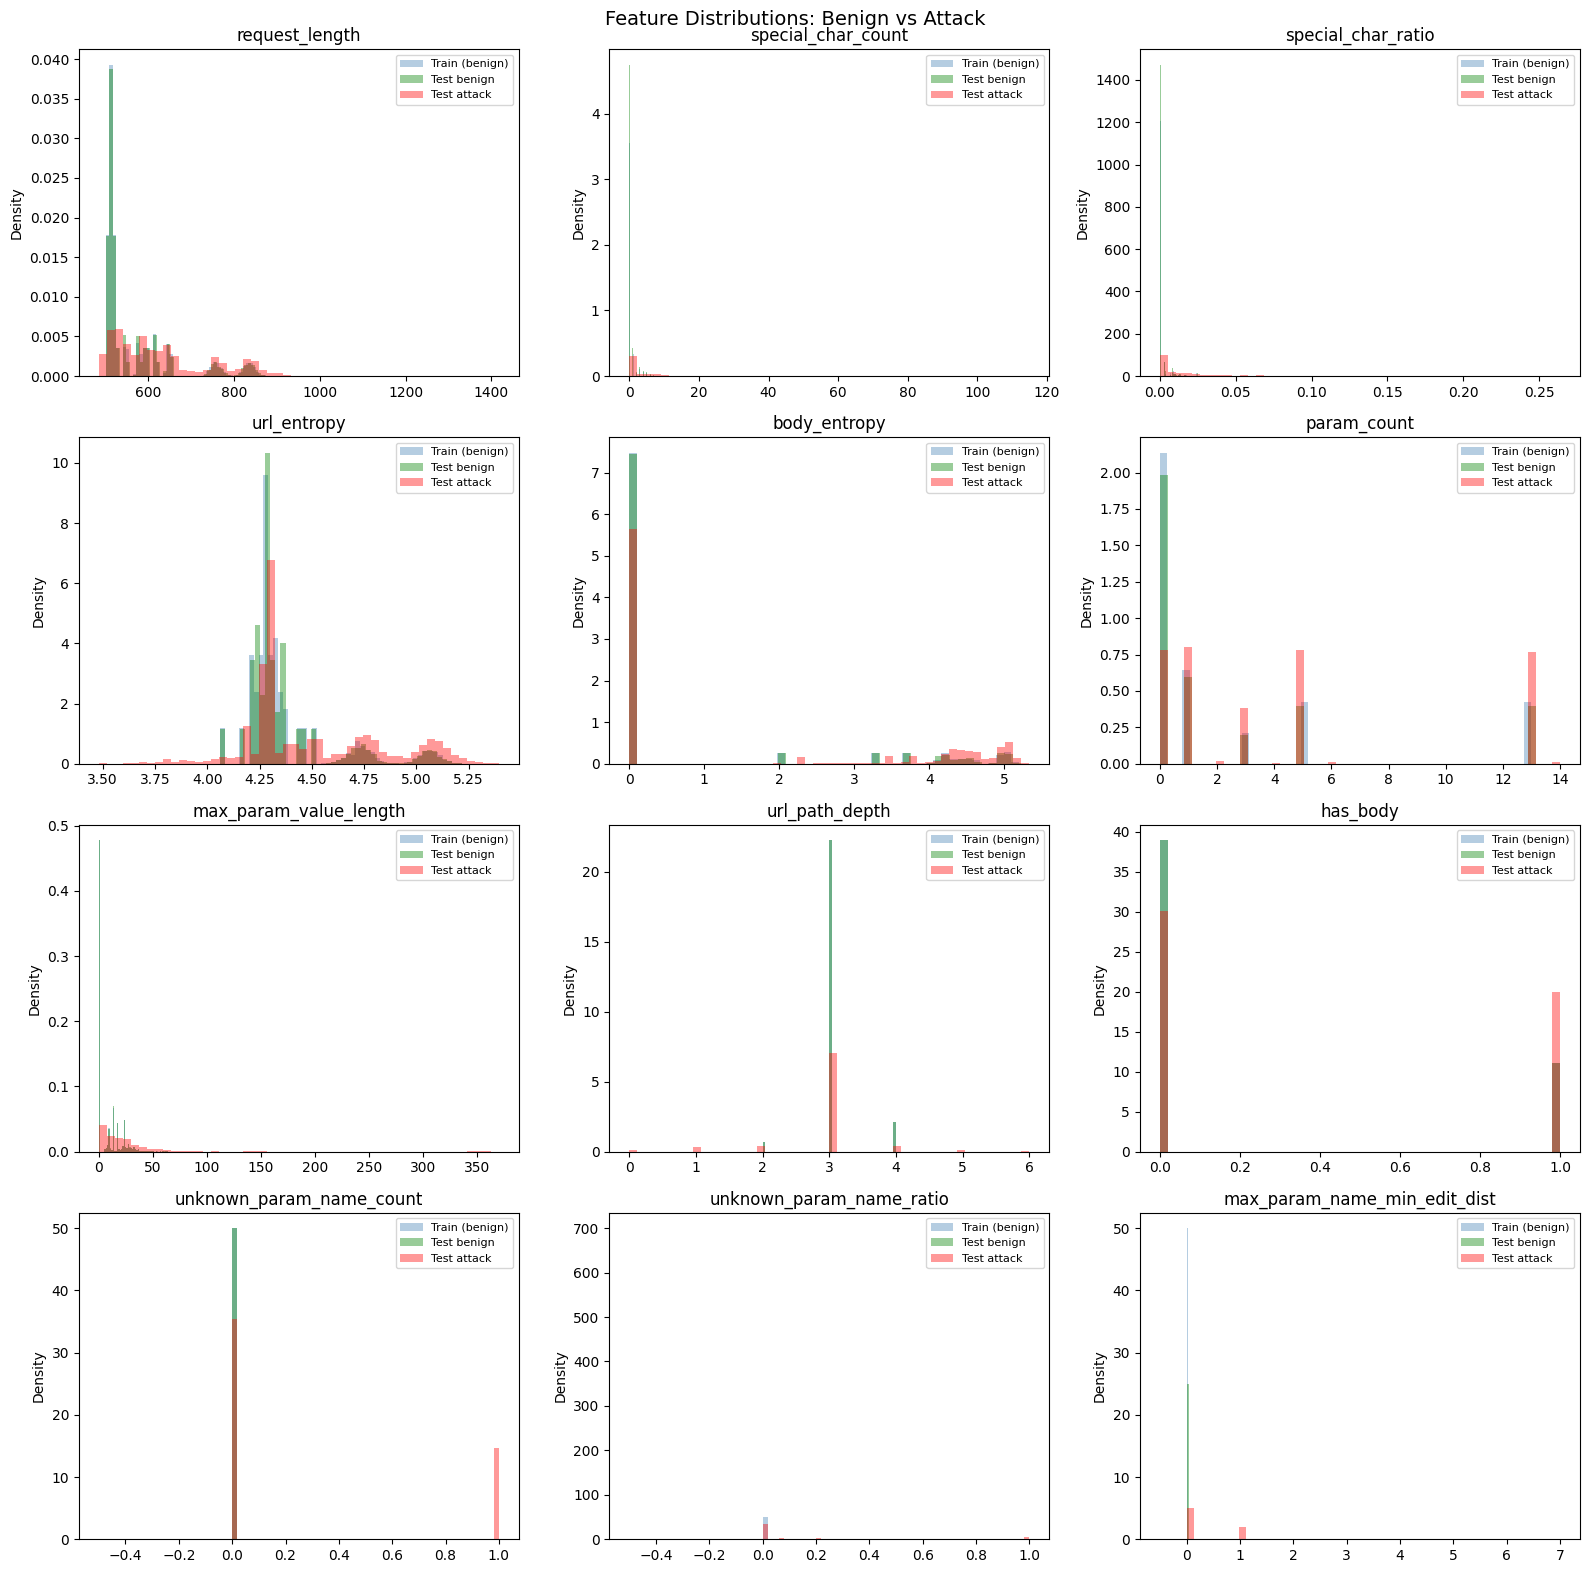

In [5]:
n_feats = len(FEATURE_COLS)
ncols = 3
nrows = math.ceil(n_feats / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
for ax in axes.flat[n_feats:]:
    ax.set_visible(False)

benign_mask = y_test == 0
attack_mask = y_test == 1

for ax, col in zip(axes.flat, FEATURE_COLS):
    ax.hist(X_train[col], bins=50, alpha=0.4, label="Train (benign)", density=True, color="steelblue")
    ax.hist(X_test.loc[benign_mask, col], bins=50, alpha=0.4, label="Test benign", density=True, color="green")
    ax.hist(X_test.loc[attack_mask, col], bins=50, alpha=0.4, label="Test attack", density=True, color="red")
    ax.set_title(col)
    ax.legend(fontsize=8)
    ax.set_ylabel("Density")

fig.suptitle("Feature Distributions: Benign vs Attack", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Scale Features & Train Isolation Forest

- `StandardScaler` fit on **training set only** (benign), applied to both train and test.
- `contamination="auto"` — correct for benign-only training (no known anomaly rate).
- `n_estimators=200` — more trees for stable scores on small-to-medium datasets.

In [6]:
# ── Train / val split ──────────────────────────────────────
X_fit, X_val = train_test_split(
    X_train, test_size=VAL_SIZE, random_state=RANDOM_STATE
)
print(f"Fit set: {len(X_fit):,}   Val set: {len(X_val):,} (benign-only, for threshold tuning)")

# ── Fit scaler on fit set only ─────────────────────────────
scaler = StandardScaler()
X_fit_scaled = scaler.fit_transform(X_fit[FEATURE_COLS])
X_val_scaled = scaler.transform(X_val[FEATURE_COLS])
X_test_scaled = scaler.transform(X_test[FEATURE_COLS])

# ── Train Isolation Forest ─────────────────────────────────
model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    max_samples=256,
    max_features=0.7,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(X_fit_scaled)

print("Isolation Forest trained.")
print(f"  n_estimators: {model.n_estimators}")
print(f"  offset_:      {model.offset_:.4f}")

Fit set: 28,800   Val set: 7,200 (benign-only, for threshold tuning)
Isolation Forest trained.
  n_estimators: 300
  offset_:      -0.5000


## 5b. FPR-Targeted Threshold Tuning

Set the `decision_function` threshold so that the false positive rate on
held-out benign validation data matches `TARGET_FPR`. This gives L2 a
controlled FPR, leaving borderline traffic for L3 to evaluate.

Threshold tuning on 7,200 benign validation samples:
  Default predict() FPR: 0.4250
  Tuned threshold:       -0.1172  (target FPR=0.05)
  Tuned FPR on val:      0.0500


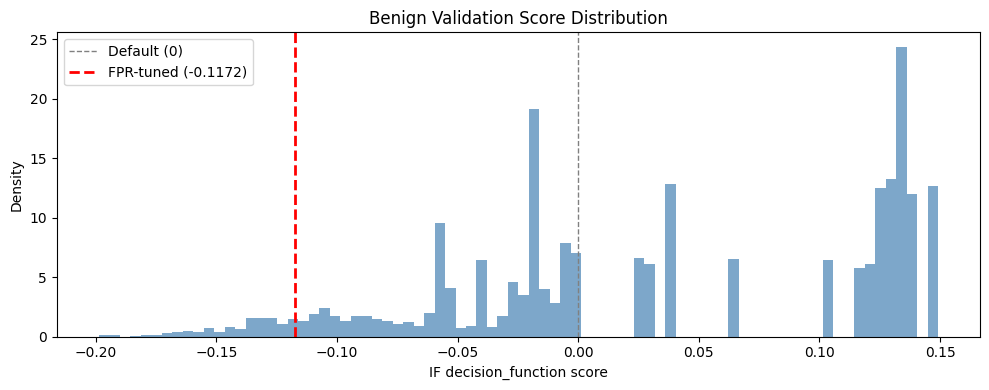

In [7]:
val_scores = model.decision_function(X_val_scaled)

# Threshold: percentile such that TARGET_FPR fraction of benign falls below it
fpr_threshold = np.percentile(val_scores, TARGET_FPR * 100)

val_preds_default = np.where(model.predict(X_val_scaled) == -1, 1, 0)
val_preds_tuned = np.where(val_scores < fpr_threshold, 1, 0)

print(f"Threshold tuning on {len(X_val):,} benign validation samples:")
print(f"  Default predict() FPR: {val_preds_default.mean():.4f}")
print(f"  Tuned threshold:       {fpr_threshold:.4f}  (target FPR={TARGET_FPR})")
print(f"  Tuned FPR on val:      {val_preds_tuned.mean():.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(val_scores, bins=80, color="steelblue", alpha=0.7, density=True)
ax.axvline(0, color="gray", ls="--", lw=1, label="Default (0)")
ax.axvline(fpr_threshold, color="red", ls="--", lw=2, label=f"FPR-tuned ({fpr_threshold:.4f})")
ax.set_xlabel("IF decision_function score")
ax.set_ylabel("Density")
ax.set_title("Benign Validation Score Distribution")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Score Distribution

`decision_function` returns scores: negative = more anomalous, positive = more normal.
Check separation between benign and attack distributions.

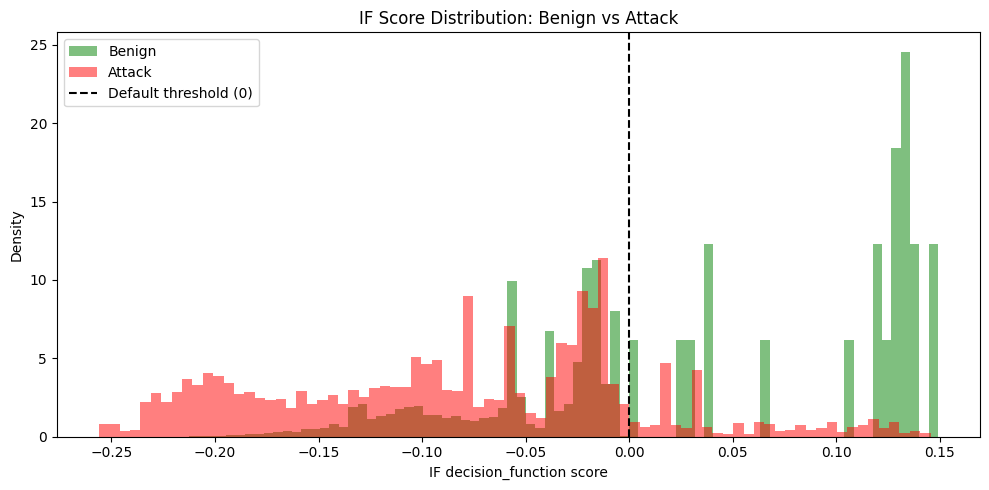

Benign scores — mean: 0.0375, std: 0.0896
Attack scores — mean: -0.0831, std: 0.0863


In [8]:
scores_test = model.decision_function(X_test_scaled)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(scores_test[benign_mask], bins=80, alpha=0.5, label="Benign", density=True, color="green")
ax.hist(scores_test[attack_mask], bins=80, alpha=0.5, label="Attack", density=True, color="red")
ax.axvline(0, color="black", ls="--", lw=1.5, label="Default threshold (0)")
ax.set_xlabel("IF decision_function score")
ax.set_ylabel("Density")
ax.set_title("IF Score Distribution: Benign vs Attack")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Benign scores — mean: {scores_test[benign_mask].mean():.4f}, "
      f"std: {scores_test[benign_mask].std():.4f}")
print(f"Attack scores — mean: {scores_test[attack_mask].mean():.4f}, "
      f"std: {scores_test[attack_mask].std():.4f}")

## 7. Evaluation at Default Threshold

=== Default threshold (score < 0 → anomaly) ===

              precision    recall  f1-score   support

      Benign       0.87      0.58      0.70     36000
      Attack       0.59      0.88      0.71     25065

    accuracy                           0.70     61065
   macro avg       0.73      0.73      0.70     61065
weighted avg       0.76      0.70      0.70     61065



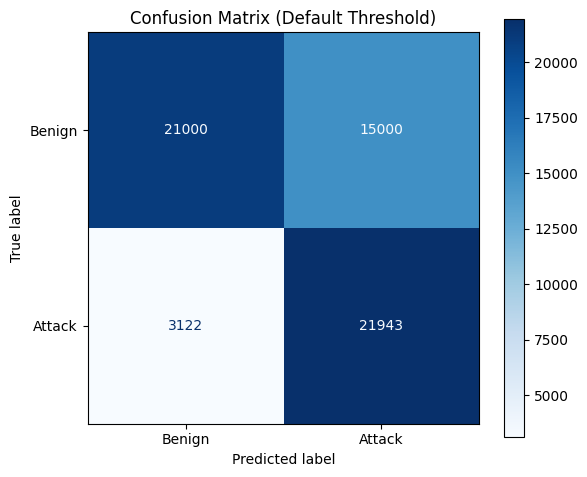

In [9]:
# IF predict: 1 = normal, -1 = anomaly
# Map to our convention: 0 = benign, 1 = attack
y_pred_default = np.where(model.predict(X_test_scaled) == -1, 1, 0)

print("=== Default threshold (score < 0 → anomaly) ===\n")
print(classification_report(y_test, y_pred_default, target_names=["Benign", "Attack"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_default,
    display_labels=["Benign", "Attack"],
    cmap="Blues", ax=ax,
)
ax.set_title("Confusion Matrix (Default Threshold)")
plt.tight_layout()
plt.show()

## 8. Threshold Sweep

Sweep the `decision_function` threshold to find the operating point that
maximizes F1. Report the full precision-recall curve.

PR-AUC: 0.7719
Best F1: 0.7165 at IF score threshold: 0.0252
  Precision: 0.5890
  Recall:    0.9146


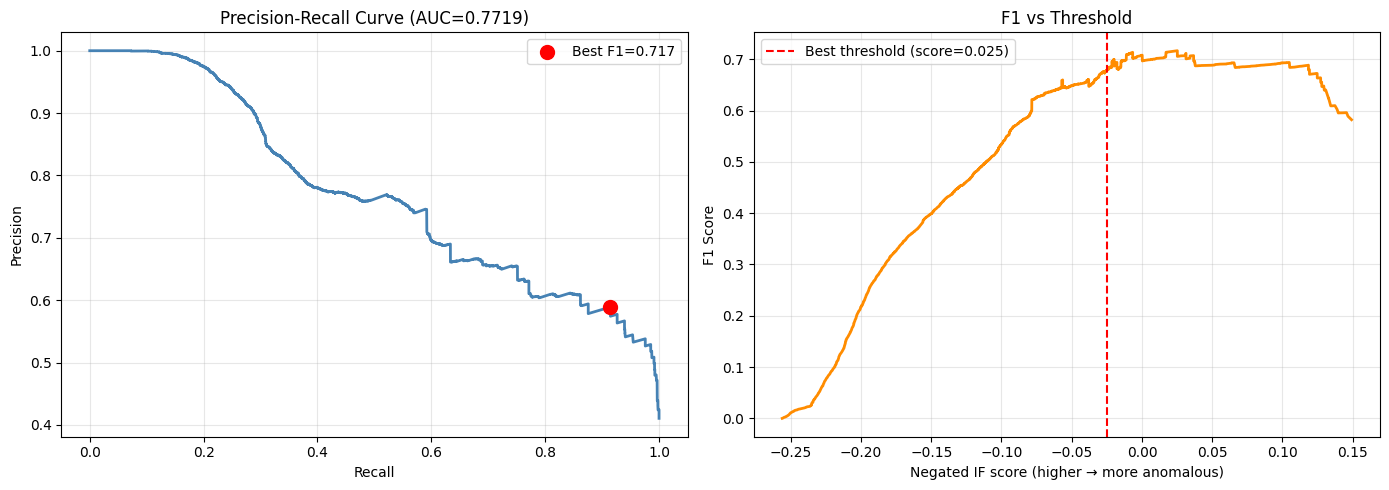

In [10]:
# Negate scores: sklearn PR curve expects higher = more positive class
# Our positive class = attack, IF gives lower scores to anomalies
neg_scores = -scores_test

precisions, recalls, thresholds_pr = precision_recall_curve(y_test, neg_scores)
pr_auc = average_precision_score(y_test, neg_scores)

# F1 at each threshold
f1s = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = np.argmax(f1s)
best_neg_thresh = thresholds_pr[best_idx]
best_thresh = -best_neg_thresh   # convert back to IF score space
f1_threshold = best_thresh

print(f"PR-AUC: {pr_auc:.4f}")
print(f"Best F1: {f1s[best_idx]:.4f} at IF score threshold: {best_thresh:.4f}")
print(f"  Precision: {precisions[best_idx]:.4f}")
print(f"  Recall:    {recalls[best_idx]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
axes[0].plot(recalls, precisions, lw=2, color="steelblue")
axes[0].scatter(recalls[best_idx], precisions[best_idx], color="red", s=100, zorder=5,
                label=f"Best F1={f1s[best_idx]:.3f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"Precision-Recall Curve (AUC={pr_auc:.4f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 vs threshold
axes[1].plot(-thresholds_pr, f1s, lw=2, color="darkorange")
axes[1].axvline(-best_thresh, color="red", ls="--", label=f"Best threshold (score={best_thresh:.3f})")
axes[1].set_xlabel("Negated IF score (higher → more anomalous)")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 vs Threshold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Evaluation at Optimal Threshold

=== Optimal threshold (IF score < 0.0252 → anomaly) ===

              precision    recall  f1-score   support

      Benign       0.90      0.56      0.69     36000
      Attack       0.59      0.91      0.72     25065

    accuracy                           0.70     61065
   macro avg       0.75      0.74      0.70     61065
weighted avg       0.77      0.70      0.70     61065



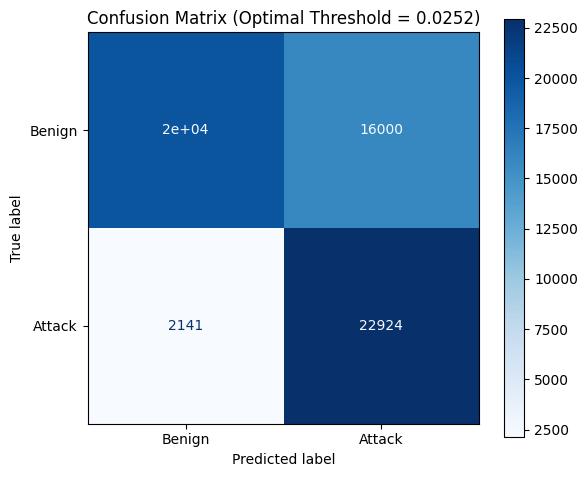


=== FPR-tuned threshold (IF score < -0.1172 → anomaly) ===

              precision    recall  f1-score   support

      Benign       0.67      0.95      0.79     36000
      Attack       0.82      0.34      0.48     25065

    accuracy                           0.70     61065
   macro avg       0.75      0.65      0.64     61065
weighted avg       0.74      0.70      0.66     61065



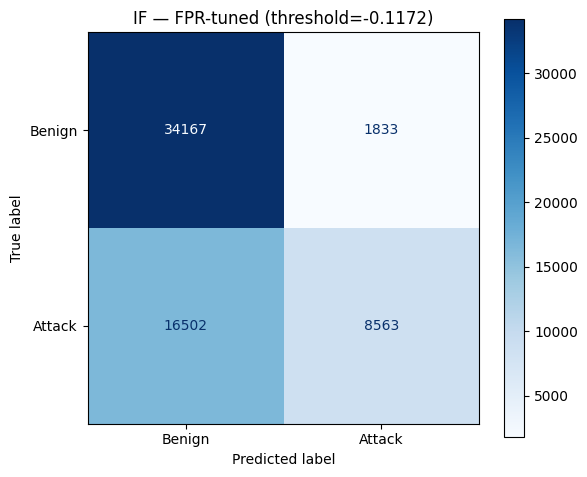

In [11]:
y_pred_opt = np.where(scores_test < best_thresh, 1, 0)

print(f"=== Optimal threshold (IF score < {best_thresh:.4f} → anomaly) ===\n")
print(classification_report(y_test, y_pred_opt, target_names=["Benign", "Attack"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_opt,
    display_labels=["Benign", "Attack"],
    cmap="Blues", ax=ax,
)
ax.set_title(f"Confusion Matrix (Optimal Threshold = {best_thresh:.4f})")
plt.tight_layout()
plt.show()

# ── FPR-tuned threshold evaluation ────────────────────────
y_pred_fpr = np.where(scores_test < fpr_threshold, 1, 0)

print(f"\n=== FPR-tuned threshold (IF score < {fpr_threshold:.4f} → anomaly) ===\n")
print(classification_report(y_test, y_pred_fpr, target_names=["Benign", "Attack"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_fpr, display_labels=["Benign", "Attack"], cmap="Blues", ax=ax,
)
ax.set_title(f"IF — FPR-tuned (threshold={fpr_threshold:.4f})")
plt.tight_layout()
plt.show()

## 10. ROC Curve

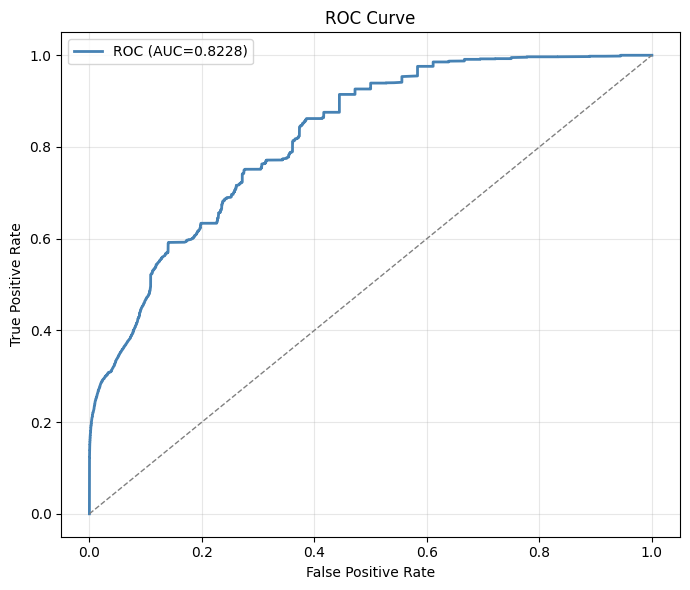

ROC-AUC: 0.8228


In [12]:
roc_auc = roc_auc_score(y_test, neg_scores)
fpr, tpr, _ = roc_curve(y_test, neg_scores)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, lw=2, color="steelblue", label=f"ROC (AUC={roc_auc:.4f})")
ax.plot([0, 1], [0, 1], ls="--", color="gray", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")

## 11. False Negative Analysis

Examine attack requests that IF missed — these are the requests Layer 3 (OC-SVM) must catch.
Understanding their feature profile informs Layer 3 design.

True Positives  (attacks caught by IF): 8,563
False Negatives (attacks missed by IF): 16,502

FN feature statistics:
       request_length  special_char_count  special_char_ratio  url_entropy  \
count        16502.00            16502.00            16502.00     16502.00   
mean           587.38                0.42                0.00         4.45   
std             87.35                0.80                0.01         0.29   
min            484.00                0.00                0.00         3.48   
25%            524.00                0.00                0.00         4.28   
50%            573.00                0.00                0.00         4.37   
75%            620.00                1.00                0.00         4.67   
max            858.00                4.00                0.03         5.24   

       body_entropy  param_count  max_param_value_length  url_path_depth  \
count      16502.00     16502.00                16502.00        16502.00   
mean           1.28         

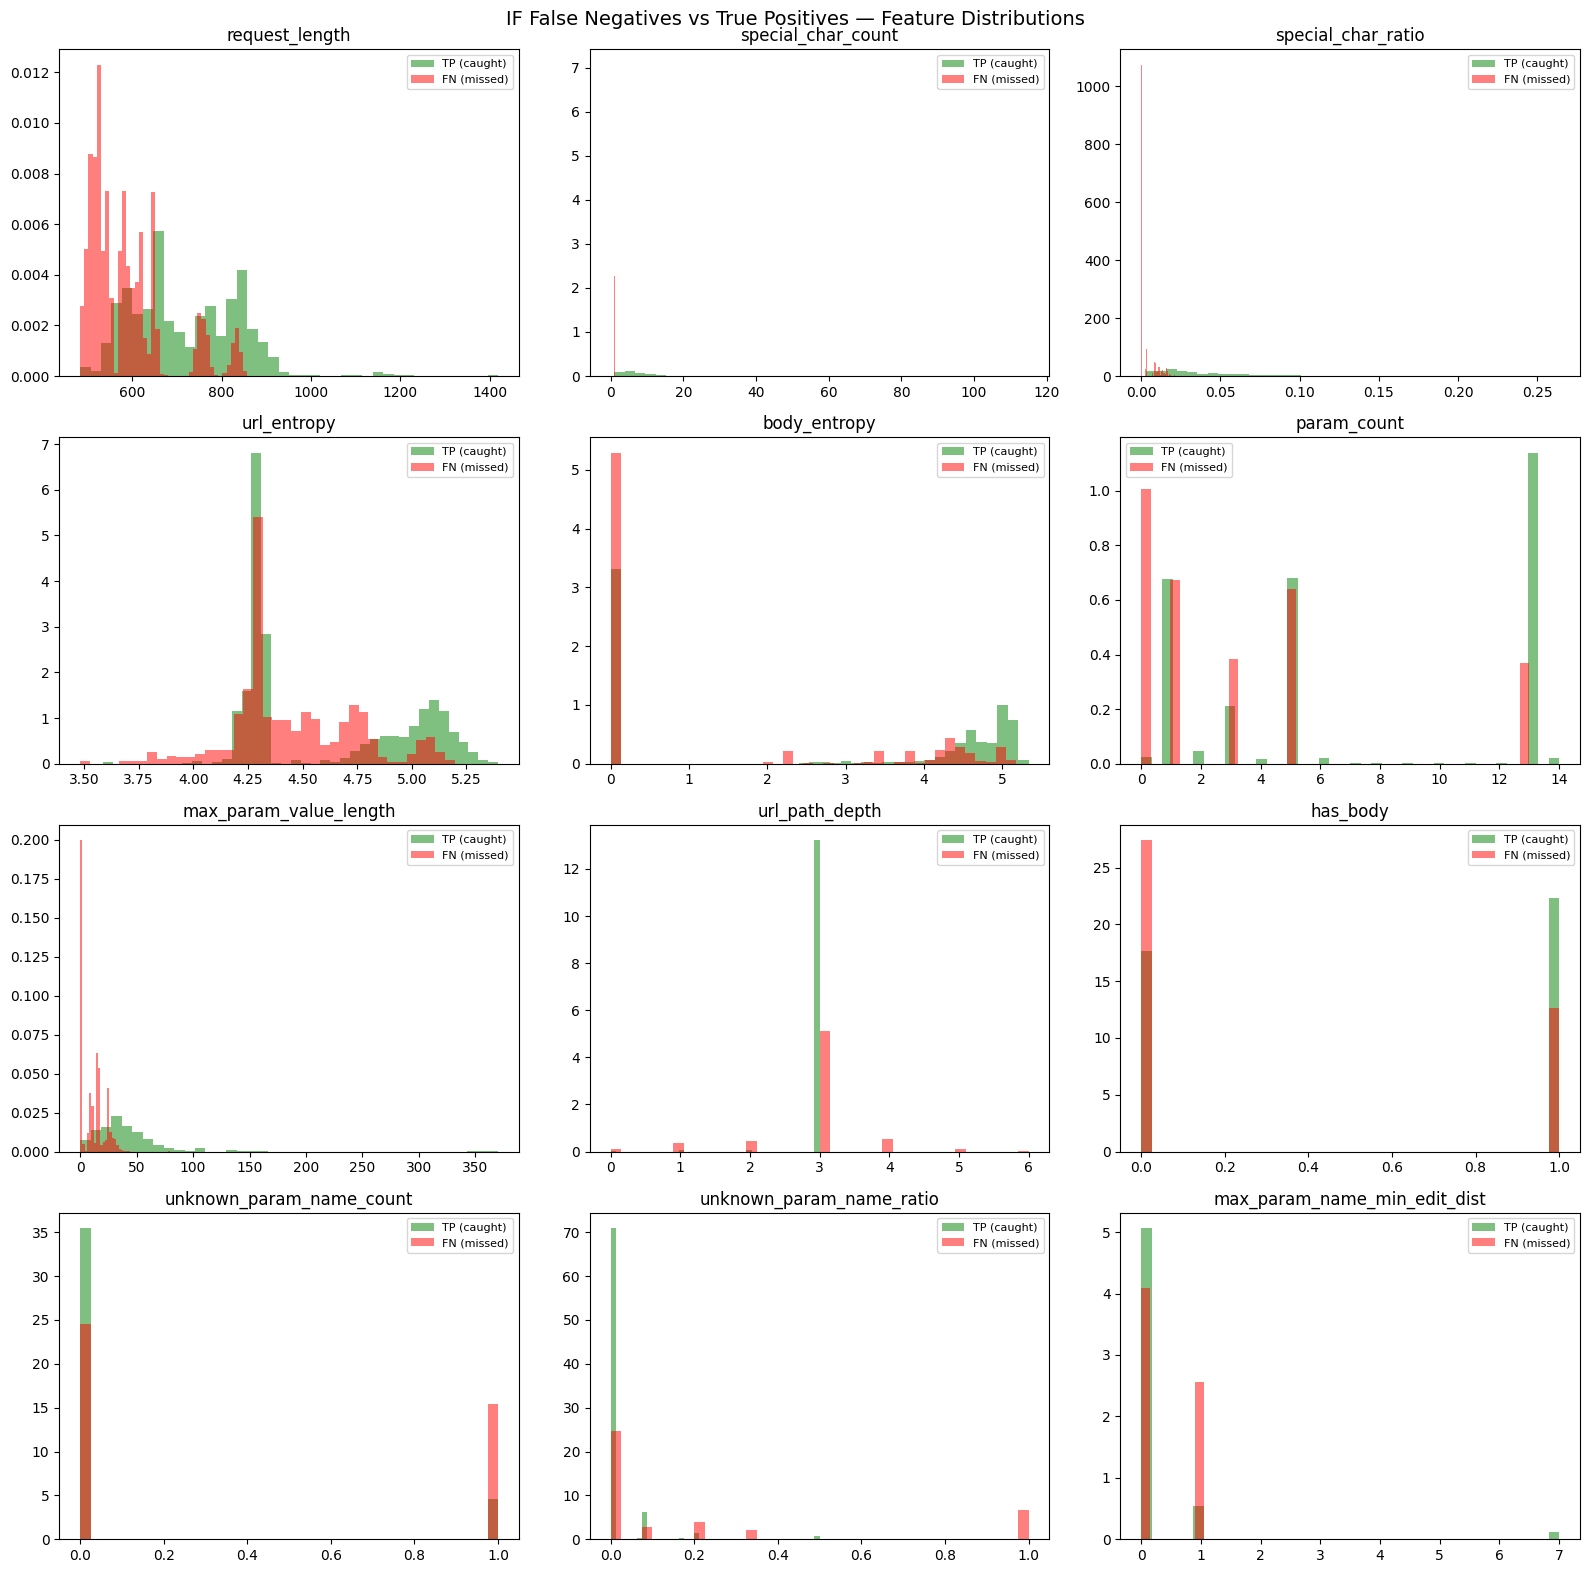

In [13]:
fn_mask = (y_test == 1) & (y_pred_fpr == 0)
tp_mask = (y_test == 1) & (y_pred_fpr == 1)

fn_features = X_test.loc[fn_mask, FEATURE_COLS]
tp_features = X_test.loc[tp_mask, FEATURE_COLS]

print(f"True Positives  (attacks caught by IF): {tp_mask.sum():,}")
print(f"False Negatives (attacks missed by IF): {fn_mask.sum():,}")
print(f"\nFN feature statistics:\n{fn_features.describe().round(2)}")
print(f"\nTP feature statistics:\n{tp_features.describe().round(2)}")

# Compare FN vs TP distributions
n_feats = len(FEATURE_COLS)
ncols = 3
nrows = math.ceil(n_feats / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
for ax in axes.flat[n_feats:]:
    ax.set_visible(False)
    
for ax, col in zip(axes.flat, FEATURE_COLS):
    ax.hist(tp_features[col], bins=40, alpha=0.5, label="TP (caught)", density=True, color="green")
    if len(fn_features) > 0:
        ax.hist(fn_features[col], bins=40, alpha=0.5, label="FN (missed)", density=True, color="red")
    ax.set_title(col)
    ax.legend(fontsize=8)
fig.suptitle("IF False Negatives vs True Positives — Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

### 11.1 Sample False Negatives

In [14]:
# Show a few FN requests to understand what IF misses
fn_df = df_test.loc[fn_mask].copy()
fn_df = fn_df.assign(**X_test.loc[fn_mask, FEATURE_COLS].to_dict())
fn_df["if_score"] = scores_test[fn_mask]

print(f"Sample false negatives (attacks missed by IF):\n")
sample_cols = ["method", "url", "body", "request_length", "special_char_count",
               "url_entropy", "param_count", "if_score"]
display_cols = [c for c in sample_cols if c in fn_df.columns]
print(fn_df[display_cols].head(10).to_string(max_colwidth=80))

Sample false negatives (attacks missed by IF):

      method                                                                              url                                                             body  request_length  special_char_count  url_entropy  param_count  if_score
36002    GET  http://localhost:8080/tienda1/publico/anadir.jsp?id=2%2F&nombre=Jam%F3n+Ib%E...                                                              NaN             580                   0     4.797182            5 -0.018916
36004    GET                                         http://localhost:8080/asf-logo-wide.gif~                                                              NaN             502                   1     4.265312            0 -0.113678
36007    GET  http://localhost:8080/tienda1/publico/autenticar.jsp?modo=entrar&login=grims...                                                              NaN             578                   0     4.775249            5 -0.015953
36009    GET  http://localho

## 12. False Positive Analysis

In [15]:
fp_mask = (y_test == 0) & (y_pred_fpr == 1)
tn_mask = (y_test == 0) & (y_pred_fpr == 0)

fp_features = X_test.loc[fp_mask, FEATURE_COLS]

print(f"True Negatives  (benign correctly passed): {tn_mask.sum():,}")
print(f"False Positives (benign flagged as attack): {fp_mask.sum():,}")
print(f"False Positive Rate: {fp_mask.sum() / (fp_mask.sum() + tn_mask.sum()):.4f}")

if fp_mask.sum() > 0:
    print(f"\nFP feature statistics:\n{fp_features.describe().round(2)}")

    # Sample FPs
    fp_df = df_test.loc[fp_mask].copy()
    fp_df = fp_df.assign(**X_test.loc[fp_mask, FEATURE_COLS].to_dict())
    fp_df["if_score"] = scores_test[fp_mask]
    sample_cols = ["method", "url", "request_length", "special_char_count",
                   "url_entropy", "param_count", "if_score"]
    display_cols = [c for c in sample_cols if c in fp_df.columns]
    print(f"\nSample false positives:\n")
    print(fp_df[display_cols].head(10).to_string(max_colwidth=80))
else:
    print("No false positives — perfect specificity at this threshold.")

True Negatives  (benign correctly passed): 34,167
False Positives (benign flagged as attack): 1,833
False Positive Rate: 0.0509

FP feature statistics:
       request_length  special_char_count  special_char_ratio  url_entropy  \
count         1833.00             1833.00             1833.00      1833.00   
mean           788.62                3.53                0.01         4.46   
std             74.14                1.74                0.01         0.32   
min            572.00                1.00                0.00         4.26   
25%            757.00                2.00                0.01         4.29   
50%            825.00                3.00                0.02         4.32   
75%            843.00                5.00                0.02         4.32   
max            895.00                9.00                0.03         5.27   

       body_entropy  param_count  max_param_value_length  url_path_depth  \
count       1833.00      1833.00                 1833.00          183

## 13. Summary

In [16]:
p_def = precision_score(y_test, y_pred_default)
r_def = recall_score(y_test, y_pred_default)
f1_def = f1_score(y_test, y_pred_default)

p_opt = precision_score(y_test, y_pred_opt)
r_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)

summary = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score", "PR-AUC", "ROC-AUC", "Threshold"],
    "Default (0)":  [f"{p_def:.4f}", f"{r_def:.4f}", f"{f1_def:.4f}", "", "", "0.0000"],
    "Optimal":      [f"{p_opt:.4f}", f"{r_opt:.4f}", f"{f1_opt:.4f}",
                     f"{pr_auc:.4f}", f"{roc_auc:.4f}", f"{best_thresh:.4f}"],
})
print(summary.to_string(index=False))

p_fpr = precision_score(y_test, y_pred_fpr)
r_fpr = recall_score(y_test, y_pred_fpr)
f1_fpr = f1_score(y_test, y_pred_fpr)

summary = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score", "PR-AUC", "ROC-AUC", "Threshold"],
    "Default (0)": [f"{p_def:.4f}", f"{r_def:.4f}", f"{f1_def:.4f}", "", "", "0.0000"],
    "F1-optimal":  [f"{p_opt:.4f}", f"{r_opt:.4f}", f"{f1_opt:.4f}", f"{pr_auc:.4f}", f"{roc_auc:.4f}", f"{f1_threshold:.4f}"],
    "FPR-tuned":   [f"{p_fpr:.4f}", f"{r_fpr:.4f}", f"{f1_fpr:.4f}", "", "", f"{fpr_threshold:.4f}"],
})
print(summary.to_string(index=False))

print(f"\nRecommendation: use FPR-tuned threshold ({fpr_threshold:.4f}) for cascade deployment.")
print(f"  Trades {r_opt - r_fpr:.1%} recall for a controlled FPR, letting L3 handle borderline traffic.")

   Metric Default (0) Optimal
Precision      0.5940  0.5889
   Recall      0.8754  0.9146
 F1-Score      0.7077  0.7165
   PR-AUC              0.7719
  ROC-AUC              0.8228
Threshold      0.0000  0.0252
   Metric Default (0) F1-optimal FPR-tuned
Precision      0.5940     0.5889    0.8237
   Recall      0.8754     0.9146    0.3416
 F1-Score      0.7077     0.7165    0.4830
   PR-AUC                 0.7719          
  ROC-AUC                 0.8228          
Threshold      0.0000     0.0252   -0.1172

Recommendation: use FPR-tuned threshold (-0.1172) for cascade deployment.
  Trades 57.3% recall for a controlled FPR, letting L3 handle borderline traffic.


## 14. Persist Scaler + Model

Save as a tuple `(scaler, model, threshold, feature_cols)` so they can never
get out of sync. Load with a single `joblib.load()` call.

In [17]:
artifact = {
    "scaler": scaler,
    "model": model,
    "threshold": fpr_threshold, #primary
    "threshold_f1_optimal": f1_threshold,
    "feature_cols": FEATURE_COLS,
    "vocab": vocab,
    "hyperparams": {
        "n_estimators": 300,
        "max_samples": 256,
        "max_features": 0.7,
        "val_size": VAL_SIZE,
        "target_fpr": TARGET_FPR,
    },
}

save_path = os.path.join(MODEL_DIR, "web_attack_if.pkl")
joblib.dump(artifact, save_path)

loaded = joblib.load(save_path)
assert list(loaded["feature_cols"]) == FEATURE_COLS
print(f"Saved to {save_path}")
print(f"  FPR-tuned threshold:  {loaded['threshold']:.4f}")
print(f"  F1-optimal threshold: {loaded['threshold_f1_optimal']:.4f}")
print(f"  Features:  {loaded['feature_cols']}")
print(f"  Scaler:    {type(loaded['scaler']).__name__}")
print(f"  Model:     {type(loaded['model']).__name__}")

Saved to ./models\web_attack_if.pkl
  FPR-tuned threshold:  -0.1172
  F1-optimal threshold: 0.0252
  Features:  ['request_length', 'special_char_count', 'special_char_ratio', 'url_entropy', 'body_entropy', 'param_count', 'max_param_value_length', 'url_path_depth', 'has_body', 'unknown_param_name_count', 'unknown_param_name_ratio', 'max_param_name_min_edit_dist']
  Scaler:    StandardScaler
  Model:     IsolationForest
